# Large scale text analysis with deep learning

В этом задании нужно сделать модель глубокого обучения, которая будет предсказывать зарплату по резюме.
Competition Kaggle- [Page](https://www.google.com/url?q=https%3A%2F%2Fwww.kaggle.com%2Fc%2Fjob-salary-prediction%2Fdata) (pick Train_rev1.*).

[yadisk url](https://yadi.sk/d/vVEOWPFY3NruT7)

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import nltk
from nltk.tokenize import WordPunctTokenizer
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DL/NLP/shad_yandex_data_scholl_2023/week2/Train_rev1.zip", compression='zip', index_col=None)
data.shape

(244768, 12)

In [4]:
data.head()

,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName
0,12612628,Engineering Systems Analyst,Engineering Systems Analyst Dorking Surrey Sal...,"Dorking, Surrey, Surrey",Dorking,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk
1,12612830,Stress Engineer Glasgow,Stress Engineer Glasgow Salary **** to **** We...,"Glasgow, Scotland, Scotland",Glasgow,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 35000/annum 25-35K,30000,cv-library.co.uk
2,12612844,Modelling and simulation analyst,Mathematical Modeller / Simulation Analyst / O...,"Hampshire, South East, South East",Hampshire,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 40000/annum 20-40K,30000,cv-library.co.uk
3,12613049,Engineering Systems Analyst / Mathematical Mod...,Engineering Systems Analyst / Mathematical Mod...,"Surrey, South East, South East",Surrey,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 30000/annum 25K-30K negotiable,27500,cv-library.co.uk
4,12613647,"Pioneer, Miser Engineering Systems Analyst","Pioneer, Miser Engineering Systems Analyst Do...","Surrey, South East, South East",Surrey,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk


Одна из проблем с предсказанием зарплат — распределение кривое: у большинства обычные зарплаты, а у некоторых — очень большие. Из-за этого получается «жирный хвост» справа, и MSE с таким работает не очень хорошо.

Есть разные способы это исправить:

-можно взять другую функцию потерь,

-предсказывать логарифм зарплаты вместо самой суммы,

-или использовать перцентили вместо реальных значений.

Пока просто будем работать с логарифмом.

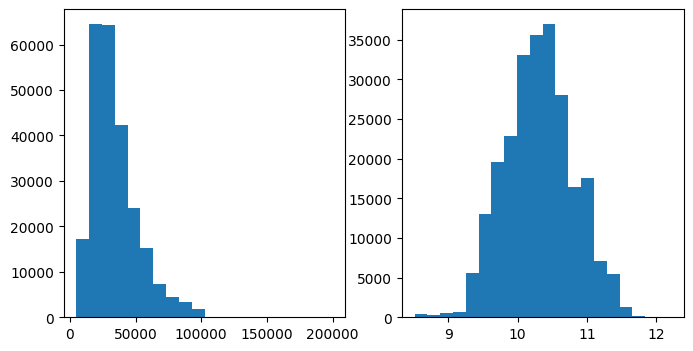

In [5]:
data['Log1pSalary'] = np.log1p(data['SalaryNormalized']).astype('float32')

plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.hist(data["SalaryNormalized"], bins=20);

plt.subplot(1, 2, 2)
plt.hist(data['Log1pSalary'], bins=20);

Наша задача — предсказать одно значение — Log1pSalary.

Для этого модель будет использовать несколько признаков:

-Текстовые: Title и FullDescription

-Категориальные: Category, Company, LocationNormalized, ContractType, ContractTime

In [6]:
text_columns = ["Title", "FullDescription"]
categorical_columns = ["Category", "Company", "LocationNormalized", "ContractType", "ContractTime"]
TARGET_COLUMN = "Log1pSalary"

data[categorical_columns] = data[categorical_columns].fillna('NaN') # cast missing values to string "NaN"

data.sample(3)

,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName,Log1pSalary
7072,64548257,Service Delivery Technical Programme Manager,Service Delivery Technical Programme Manager ...,Surrey,Surrey,full_time,permanent,Monarch Recruitment,IT Jobs,"From 45,000 to 50,000 per year",47500,planetrecruit.com,10.768506
199056,71849797,ASC Social Worker,Temporary Adult Social Care Social Worker Olde...,Clacton-On-Sea Essex South East,UK,NaN,contract,Working for Essex,Healthcare & Nursing Jobs,20.34 - 24.81 per hour,43344,totaljobs.com,10.676947
161546,71189969,Sales Executive,This position is based in our Chiswick office ...,Harrow Middlesex South East,UK,NaN,permanent,Michael Page Finance,Accounting & Finance Jobs,30000 to 45000 per annum,37500,totaljobs.com,10.532123


### Предобработка текстовых данных

Как и раньше, работа с текстом в NLP начинается с токенизации — разбиения текста на отдельные токены (слова, знаки пунктуации и т.д.).

Задача:
Привести текст в нижний регистр и токенизировать все значения в колонках Title и FullDescription.

Сохрани токены как строку, где слова разделены пробелами — так будет быстрее работать.

Можно использовать токенайзеры из nltk. Проверки настроены под WordPunctTokenizer, но небольшие отличия допустимы.

In [7]:
tokenizer = WordPunctTokenizer()

In [8]:
print("Raw text:")
print(data["FullDescription"][2::100000])

Raw text:
2         Mathematical Modeller / Simulation Analyst / O...
100002    A successful and high achieving specialist sch...
200002    Web Designer  HTML, CSS, JavaScript, Photoshop...
Name: FullDescription, dtype: object


In [9]:
def tokenizer_func(string: str) -> str:
    string = str(string)
    return ' '.join(tokenizer.tokenize(string)).lower()

In [11]:
data['Title'] = data['Title'].apply(tokenizer_func)
data['FullDescription'] = data['FullDescription'].apply(tokenizer_func)
tokenizer = nltk.tokenize.WordPunctTokenizer()

In [14]:
data[['Title', 'FullDescription']].head(5)

,Title,FullDescription
0,engineering systems analyst,engineering systems analyst dorking surrey sal...
1,stress engineer glasgow,stress engineer glasgow salary **** to **** we...
2,modelling and simulation analyst,mathematical modeller / simulation analyst / o...
3,engineering systems analyst / mathematical mod...,engineering systems analyst / mathematical mod...
4,"pioneer , miser engineering systems analyst","pioneer , miser engineering systems analyst do..."


Теперь мы можем предположить, что наш текст представляет собой список токенов, разделенных пробелами:

In [15]:
print("Tokenized:")
print(data["FullDescription"][2::100000])
assert data["FullDescription"][2][:50] == 'mathematical modeller / simulation analyst / opera'
assert data["Title"][54321] == 'international digital account manager ( german )'

Tokenized:
2         mathematical modeller / simulation analyst / o...
100002    a successful and high achieving specialist sch...
200002    web designer html , css , javascript , photosh...
Name: FullDescription, dtype: object


Не все слова одинаково полезны. Некоторые из них являются опечатками или редкими словами, которые встречаются всего несколько раз.
Давайте посчитаем, сколько раз каждое слово встречается в данных, чтобы мы могли составить "белый список" известных слов.

In [16]:
from collections import Counter
token_counts = Counter()

for title in data['Title'].values:
    for token in title.split():
        token_counts[token] += 1

for title in data['FullDescription'].values:
    for token in title.split():
        token_counts[token] += 1

In [17]:
print("Total unique tokens :", len(token_counts))
print('\n'.join(map(str, token_counts.most_common(n=5))))
print('...')
print('\n'.join(map(str, token_counts.most_common()[-3:])))

assert token_counts.most_common(1)[0][1] in  range(2600000, 2700000)
assert len(token_counts) in range(200000, 210000)
print('Correct!')

Total unique tokens : 202704
('and', 2657388)
('.', 2523216)
(',', 2318606)
('the', 2080994)
('to', 2019884)
...
('stephanietraveltraderecruitmnt', 1)
('ruabon', 1)
('lowehays', 1)
Correct!


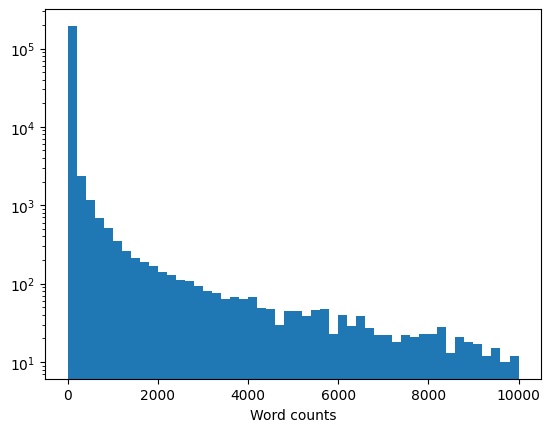

In [18]:
# Давайте посмотрим, сколько слов соответствует каждой частоте встречаемости
plt.hist(list(token_counts.values()), range=[0, 10**4], bins=50, log=True)
plt.xlabel("Word counts");

In [19]:
min_count = 10

# tokens from token_counts keys that had at least min_count occurrences throughout the dataset
tokens = sorted(t for t, c in token_counts.items() if c >= min_count)#TODO<YOUR CODE HERE>

# Add a special tokens for unknown and empty words
UNK, PAD = "UNK", "PAD"
tokens = [UNK, PAD] + tokens

In [20]:
print("Vocabulary size:", len(tokens))
assert type(tokens) == list
assert len(tokens) in range(32000, 35000)
assert 'me' in tokens
assert UNK in tokens
print("Correct!")

Vocabulary size: 34158
Correct!


Построим обратный индекс токенов: словарь, который сопоставляет токен (строку) с его индексом в списке tokens (целое число).

In [21]:
token_to_id = {token: i for i, token in enumerate(tokens)}

In [22]:
assert isinstance(token_to_id, dict)
assert len(token_to_id) == len(tokens)
for tok in tokens:
    assert tokens[token_to_id[tok]] == tok

print("Correct!")

Correct!


И наконец, давайте используем созданный вами словарь, чтобы преобразовать строки текста в матрицы, "перевариваемые" нейронной сетью.

In [23]:
UNK_IX, PAD_IX = map(token_to_id.get, [UNK, PAD])

def as_matrix(sequences, max_len=None):
    """ Convert a list of tokens into a matrix with padding """
    if isinstance(sequences[0], str):
        sequences = list(map(str.split, sequences))

    max_len = min(max(map(len, sequences)), max_len or float('inf'))

    matrix = np.full((len(sequences), max_len), np.int32(PAD_IX))
    for i,seq in enumerate(sequences):
        row_ix = [token_to_id.get(word, UNK_IX) for word in seq[:max_len]]
        matrix[i, :len(row_ix)] = row_ix

    return matrix

In [24]:
print("Lines:")
print('\n'.join(data["Title"][::100000].values), end='\n\n')
print("Matrix:")
print(as_matrix(data["Title"][::100000]))

Lines:
engineering systems analyst
hr assistant
senior ec & i engineer

Matrix:
[[10807 30161  2166     1     1]
 [15020  2844     1     1     1]
 [27645 10201    16 15215 10804]]


Теперь давайте закодируем имеющиеся у нас категориальные данные.
Как обычно, для простоты мы будем использовать one-hot-кодирование. Респект, если вы реализуете более продвинутые кодировки: tf-idf, псевдо-временные ряды и т.д.

In [25]:
from sklearn.feature_extraction import DictVectorizer

# we only consider top-1k most frequent companies to minimize memory usage
top_companies, top_counts = zip(*Counter(data['Company']).most_common(1000))
recognized_companies = set(top_companies)
data["Company"] = data["Company"].apply(lambda comp: comp if comp in recognized_companies else "Other")

categorical_vectorizer = DictVectorizer(dtype=np.float32, sparse=False)
categorical_vectorizer.fit(data[categorical_columns].apply(dict, axis=1))

DictVectorizer(dtype=<class 'numpy.float32'>, sparse=False)

### Часть с глубоким обучением
Теперь, когда мы научились токенизировать данные, давайте спроектируем эксперимент по машинному обучению.
Как и ранее, мы не будем слишком сильно сосредотачиваться на валидации, выбрав простое разделение на обучающую и тестовую выборки.
Строго говоря, мы совершили здесь небольшое преступление: мы использовали все данные для токенизации и построения словаря. Более строгий подход заключался бы в том, чтобы выполнять эту часть только на обучающем наборе. Вы можете попробовать сделать это и измерить величину изменений.

In [26]:
data_train, data_val = train_test_split(data, test_size=0.2, random_state=42)
data_train.index = range(len(data_train))
data_val.index = range(len(data_val))

print("Train size = ", len(data_train))
print("Validation size = ", len(data_val))

Train size =  195814
Validation size =  48954


In [27]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Преобразует numpy batch в torch.Tensor, перемещая их на указанное device.
def to_tensors(batch, device):
    batch_tensors = dict()
    for key, arr in batch.items():
        if key in ["FullDescription", "Title"]:
            batch_tensors[key] = torch.tensor(arr, device=device, dtype=torch.int64)
        else:
            batch_tensors[key] = torch.tensor(arr, device=device)
    return batch_tensors

# Функция для Подготовки Батчей Данных
def make_batch(data, max_len=None, word_dropout=0, device=device):
    """
    Creates a keras-friendly dict from the batch data.
    :param word_dropout: replaces token index with UNK_IX with this probability
    :returns: a dict with {'title' : int64[batch, title_max_len]
    """
    batch = {}
    batch["Title"] = as_matrix(data["Title"].values, max_len)
    batch["FullDescription"] = as_matrix(data["FullDescription"].values, max_len)
    batch['Categorical'] = categorical_vectorizer.transform(data[categorical_columns].apply(dict, axis=1))

    if word_dropout != 0:
        batch["FullDescription"] = apply_word_dropout(batch["FullDescription"], 1. - word_dropout)

    if TARGET_COLUMN in data.columns:
        batch[TARGET_COLUMN] = data[TARGET_COLUMN].values

    return to_tensors(batch, device)

def apply_word_dropout(matrix, keep_prop, replace_with=UNK_IX, pad_ix=PAD_IX,):
    dropout_mask = np.random.choice(2, np.shape(matrix), p=[keep_prop, 1 - keep_prop])
    dropout_mask &= matrix != pad_ix
    return np.choose(dropout_mask, [matrix, np.full_like(matrix, replace_with)])

In [28]:
make_batch(data_train[:3], max_len=10)

{'Title': tensor([[27645, 29893, 33674,     1,     1,     1,     1],
         [29239,   197, 19175, 20042, 15554, 23162,  4051],
         [10609, 30412, 17746,    33,  8705, 29157,    65]], device='cuda:0'),
 'FullDescription': tensor([[27645, 29893, 33674, 32939,   982, 27645, 29893, 33674, 16451, 32939],
         [29239,   197, 19175, 20042, 15554, 23162,  4051, 25511,   907,    82],
         [30746, 21956, 20601,  6409, 16451,  8165, 27493,   982, 30412, 17746]],
        device='cuda:0'),
 'Categorical': tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0'),
 'Log1pSalary': tensor([ 9.7115, 10.4631, 10.7144], device='cuda:0')}

#### Архитектура модели

Наша базовая модель состоит из трех ветвей:
Кодировщик для названия (Title)
Кодировщик для описания (Description)
Кодировщик для категориальных признаков
Затем мы подадим выходы всех 3 ветвей в одну общую сеть, которая будет предсказывать зарплату.
![scheme](https://github.com/yandexdataschool/nlp_course/raw/master/resources/w2_conv_arch.png)

In [29]:
class SalaryPredictor(nn.Module):
    def __init__(self, n_tokens, n_cat_features=len(categorical_vectorizer.vocabulary_), hid_size=64):
        super().__init__()

        self.title_embeddings = nn.Embedding(n_tokens, hid_size)
        self.description_embeddings = nn.Embedding(n_tokens, hid_size)

        self.title_lstm = nn.LSTM(hid_size, hid_size, batch_first=True)
        self.description_lstm = nn.LSTM(hid_size, hid_size, batch_first=True)

        self.categorical_mlp = nn.Sequential(
            nn.Linear(n_cat_features, hid_size * 2),
            nn.ReLU(),
            nn.Linear(hid_size * 2, hid_size),
        )

        self.final_mlp = nn.Sequential(
            nn.Linear(hid_size * 3, hid_size),
            nn.ReLU(),
            nn.Linear(hid_size, 1),
        )

    def forward(self, batch):
        title_ix = batch['Title']
        title_embeds = self.title_embeddings(title_ix)
        _, (title_hidden, _) = self.title_lstm(title_embeds)
        title_features = title_hidden.squeeze(0)

        desc_ix = batch['FullDescription']
        desc_embeds = self.description_embeddings(desc_ix)
        _, (desc_hidden, _) = self.description_lstm(desc_embeds)
        desc_features = desc_hidden.squeeze(0)

        cat_features = self.categorical_mlp(batch['Categorical'])

        combined_features = torch.cat([title_features, desc_features, cat_features], dim=1)
        prediction = self.final_mlp(combined_features)

        return prediction.squeeze(-1)

In [32]:
model = SalaryPredictor(n_tokens=len(tokens)).to(device)
batch = make_batch(data_train[:100], device=device)
criterion = nn.MSELoss()

dummy_pred = model(batch)
dummy_loss = criterion(dummy_pred, batch[TARGET_COLUMN])
assert dummy_pred.shape == torch.Size([100])
assert len(torch.unique(dummy_pred)) > 20, "model returns suspiciously few unique outputs. Check your initialization"
assert dummy_loss.ndim == 0 and 0. <= dummy_loss <= 250., "make sure you minimize MSE"

#### Обучение и оценка
Как обычно, мы будем "кормить" нашего "монстра" случайными мини-батчами данных.
По мере обучения мы хотим отслеживать не только функцию потерь, которая вычисляется в логарифмическом пространстве, но и фактическую ошибку, измеряемую в долларах.

In [33]:
def iterate_minibatches(data, batch_size=256, shuffle=True, cycle=False, device=device, **kwargs):
    """ iterates minibatches of data in random order """
    while True:
        indices = np.arange(len(data))
        if shuffle:
            indices = np.random.permutation(indices)

        for start in range(0, len(indices), batch_size):
            batch = make_batch(data.iloc[indices[start : start + batch_size]], device=device, **kwargs)
            yield batch

        if not cycle: break

In [34]:
from tqdm.auto import tqdm

BATCH_SIZE = 16
EPOCHS = 5

In [35]:
def print_metrics(model, data, batch_size=BATCH_SIZE, name="", device=torch.device('cpu'), **kw):
    squared_error = abs_error = num_samples = 0.0
    model.eval()
    with torch.no_grad():
        for batch in iterate_minibatches(data, batch_size=batch_size, shuffle=False, device=device, **kw):
            batch_pred = model(batch)
            squared_error += torch.sum(torch.square(batch_pred - batch[TARGET_COLUMN]))
            abs_error += torch.sum(torch.abs(batch_pred - batch[TARGET_COLUMN]))
            num_samples += len(batch_pred)
    mse = squared_error.detach().cpu().numpy() / num_samples
    mae = abs_error.detach().cpu().numpy() / num_samples
    print("%s results:" % (name or ""))
    print("Mean square error: %.5f" % mse)
    print("Mean absolute error: %.5f" % mae)
    return mse, mae


In [36]:
model = SalaryPredictor(n_tokens=len(tokens)).to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)

for epoch in range(EPOCHS):
    print(f"epoch: {epoch}")
    model.train()
    for i, batch in tqdm(enumerate(
            iterate_minibatches(data_train, batch_size=BATCH_SIZE, device=device)),
            total=len(data_train) // BATCH_SIZE
        ):
        pred = model(batch)
        loss = criterion(pred, batch[TARGET_COLUMN])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print_metrics(model, data_val, device=device)

epoch: 0


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.17747
Mean absolute error: 0.33004
epoch: 1


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.15434
Mean absolute error: 0.30694
epoch: 2


...

 results:
Mean square error: 0.13733
Mean absolute error: 0.28778
epoch: 3


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.13318
Mean absolute error: 0.28334
epoch: 4


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.12615
Mean absolute error: 0.27402


In [45]:
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score

def print_metrics(model, data, batch_size=BATCH_SIZE, name="", device=torch.device('cpu'), **kw):
    squared_error_log = abs_error_log = num_samples = 0.0
    all_preds_log = []
    all_targets_log = []

    model.eval()
    with torch.no_grad():
        for batch in iterate_minibatches(data, batch_size=batch_size, shuffle=False, device=device, cycle=False, **kw):
            batch_pred_log = model(batch)

            # Для расчета лог-метрик
            squared_error_log += torch.sum(torch.square(batch_pred_log - batch[TARGET_COLUMN]))
            abs_error_log += torch.sum(torch.abs(batch_pred_log - batch[TARGET_COLUMN]))

            # Для расчета R2 и MAPE на оригинальных значениях
            all_preds_log.append(batch_pred_log.detach().cpu().numpy())
            all_targets_log.append(batch[TARGET_COLUMN].detach().cpu().numpy())
            num_samples += len(batch_pred_log)

    # Метрики в логарифмическом масштабе
    mse_log = squared_error_log.cpu().numpy() / num_samples
    mae_log = abs_error_log.cpu().numpy() / num_samples

    # Преобразование в оригинальный масштаб
    preds_log_np = np.concatenate(all_preds_log)
    targets_log_np = np.concatenate(all_targets_log)

    preds_salary = np.expm1(preds_log_np) # np.expm1(x) = exp(x) - 1
    targets_salary = np.expm1(targets_log_np)

    # Вычисление R2
    r2 = r2_score(targets_salary, preds_salary)

    # Вычисление MAPE
    # Избегаем деления на ноль, если target_salary может быть 0 (что для зарплат маловероятно, но лучше подстраховаться)
    # Если target_salary равно 0, то этот элемент можно исключить или обработать отдельно.
    # Для целей этой задачи, будем считать, что зарплаты > 0.
    # np.seterr(divide='ignore', invalid='ignore') # Отключить предупреждения о делении на ноль
    percentage_errors = np.abs((targets_salary - preds_salary) / targets_salary)
    mape = np.mean(percentage_errors) * 100 # В процентах


    print("%s results:" % (name or ""))
    print("Mean square error (log): %.5f" % mse_log)
    print("Mean absolute error (log): %.5f" % mae_log)
    print("R^2 (original scale): %.4f" % r2)
    print("Mean Absolute Percentage Error (MAPE): %.2f%%" % mape)

    return mse_log, mae_log, r2, mape # Возвращаем все метрики


In [48]:
mse_log, mae_log, r2, mape = print_metrics(model, data_val, batch_size=BATCH_SIZE, device=device)


 results:
Mean square error (log): 0.12615
Mean absolute error (log): 0.27402
R^2 (original scale): 0.4188
Mean Absolute Percentage Error (MAPE): 30.07%
